In [1]:
library(clusterProfiler)
library(org.Hs.eg.db) 



clusterProfiler v4.14.3 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbi

In [ ]:
library(ggplot2)
library(ggrepel)
library(Seurat)
library(dplyr)
library(purrr)
library(tibble)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


## Overall pattern

In [3]:
obj.gage <- readRDS("/home/xinyuelu/AD-proj/results/results-annotate-hPFC/annotation/AD_rna_annotated.rds")

In [4]:
head(obj.gage@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,DNA.coverage.all,DNA.coverage.all.chr16,DNA.coverage.all.chrX,DNA.coverage.all.chr17,DNA.coverage.all.chr20,DNA.coverage.all.chr19,DNA.coverage.all.chr18,⋯,sex,condition,dataset,dataset2,doublet,RNA_snn_res.3,seurat_clusters,raw.ident,major_cell_type,sub_cell_type
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
"hPFC-lib-1_A1,A7",hPFC-lib-1,4495,1258,64012,1311.5,3013.5,1337.5,1291.0,515.5,1982.5,⋯,Female,CT,GAGE-seq,hPFC-lib-1,0,19,19,19,Micro,Micro
"hPFC-lib-1_A1,C5",hPFC-lib-1,3582,1116,303281,5662.5,8227.0,6490.0,4778.0,2766.0,8379.0,⋯,Male,AD,GAGE-seq,hPFC-lib-1,0,18,18,18,OPC,OPC
"hPFC-lib-1_A1,C8",hPFC-lib-1,6806,1685,429266,8691.5,11564.5,9076.5,7904.5,4953.5,12643.0,⋯,Male,AD,GAGE-seq,hPFC-lib-1,0,7,7,7,Oligo,Oligo
"hPFC-lib-1_A1,C12",hPFC-lib-1,11859,2334,149474,2839.0,3947.5,2939.5,2614.5,1462.0,4921.5,⋯,Male,AD,GAGE-seq,hPFC-lib-1,0,15,15,15,Inh,Inh Sst
"hPFC-lib-1_A1,D2",hPFC-lib-1,10160,1993,78132,1376.0,2138.0,1488.0,1187.5,577.0,2140.0,⋯,Male,AD,GAGE-seq,hPFC-lib-1,0,0,0,0,Oligo,Oligo
"hPFC-lib-1_A1,E1",hPFC-lib-1,10873,2376,301633,6108.5,7882.0,5742.5,5678.0,3119.0,9025.0,⋯,Male,CT,GAGE-seq,hPFC-lib-1,0,22,22,22,OPC,OPC


In [3]:
filter_DEGs <- function(file_path) {
  df <- read.csv(file_path, stringsAsFactors = FALSE)
  
  colnames(df)[1] <- "gene_name"
  
  filtered_df <- df[df$p_val_adj <= 0.05 & 
                      abs(df$avg_log2FC) > 0.25 & 
                      df$pct.1 > 0.2 & 
                      df$pct.2 > 0.2, ]

  return(filtered_df$gene_name)
}

In [4]:
cell_types <- c("Exc", "Inh", "Astro", "Micro", "Oligo", "OPC")

In [5]:
sex_base_dir <- "/home/xinyuelu/AD-proj/results/results-annotate-hPFC/DEG_hPFC-lib-all/sex/major-cell-type"
base_dir <- "/home/xinyuelu/AD-proj/results/results-annotate-hPFC/DEG_hPFC-lib-all/all/major-cell-type"

In [6]:
sex_ad_deg_list <- c()
for (c in cell_types) {
    AD_degs <- filter_DEGs(file.path(sex_base_dir, paste0(c, "-AD-F-vs-M-MAST.csv")))
    CT_degs <- filter_DEGs(file.path(sex_base_dir, paste0(c, "-CT-F-vs-M-MAST.csv")))
    unique_AD_degs <- setdiff(AD_degs, CT_degs)
    sex_ad_deg_list[[c]] <- unique_AD_degs
    print(c)
    print(length(unique_AD_degs))
}

[1] "Exc"
[1] 374
[1] "Inh"
[1] 14
[1] "Astro"
[1] 110
[1] "Micro"
[1] 22
[1] "Oligo"
[1] 161
[1] "OPC"
[1] 9


## XCI

In [3]:
obj.gage <- readRDS("/home/xinyuelu/AD-proj/results/results-annotate-hPFC/annotation/AD_rna_annotated.rds")

In [5]:
colnames(obj.gage@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
  [3] "nFeature_RNA"                "DNA.coverage.all"           
  [5] "DNA.coverage.all.chr16"      "DNA.coverage.all.chrX"      
  [7] "DNA.coverage.all.chr17"      "DNA.coverage.all.chr20"     
  [9] "DNA.coverage.all.chr19"      "DNA.coverage.all.chr18"     
 [11] "DNA.coverage.all.chr22"      "DNA.coverage.all.chr21"     
 [13] "DNA.coverage.all.chrY"       "DNA.coverage.all.chrM"      
 [15] "DNA.coverage.all.chr2"       "DNA.coverage.all.chr5"      
 [17] "DNA.coverage.all.chr7"       "DNA.coverage.all.chr6"      
 [19] "DNA.coverage.all.chr15"      "DNA.coverage.all.chr11"     
 [21] "DNA.coverage.all.chr13"      "DNA.coverage.all.chr8"      
 [23] "DNA.coverage.all.chr12"      "DNA.coverage.all.chr3"      
 [25] "DNA.coverage.all.chr9"       "DNA.coverage.all.chr14"     
 [27] "DNA.coverage.all.chr4"       "DNA.coverage.all.chr10"     
 [29] "DNA.coverage.all.chr1"       "DNA.coverage.inter"         
 [31] "DNA.coverage.inter.chr16"    "DNA.coverage.inter.chrX"    
 [33] "DNA.coverage.inter.chr17"    "DNA.coverage.inter.chr20"   
 [35] "DNA.coverage.inter.chr19"    "DNA.coverage.inter.chr18"   
 [37] "DNA.coverage.inter.chr22"    "DNA.coverage.inter.chr21"   
 [39] "DNA.coverage.inter.chrY"     "DNA.coverage.inter.chrM"    
 [41] "DNA.coverage.inter.chr2"     "DNA.coverage.inter.chr5"    
 [43] "DNA.coverage.inter.chr7"     "DNA.coverage.inter.chr6"    
 [45] "DNA.coverage.inter.chr15"    "DNA.coverage.inter.chr11"   
 [47] "DNA.coverage.inter.chr13"    "DNA.coverage.inter.chr8"    
 [49] "DNA.coverage.inter.chr12"    "DNA.coverage.inter.chr3"    
 [51] "DNA.coverage.inter.chr9"     "DNA.coverage.inter.chr14"   
 [53] "DNA.coverage.inter.chr4"     "DNA.coverage.inter.chr10"   
 [55] "DNA.coverage.inter.chr1"     "DNA.coverage.intra"         
 [57] "DNA.coverage.intra.chr16"    "DNA.coverage.intra.chrX"    
 [59] "DNA.coverage.intra.chr17"    "DNA.coverage.intra.chr20"   
 [61] "DNA.coverage.intra.chr19"    "DNA.coverage.intra.chr18"   
 [63] "DNA.coverage.intra.chr22"    "DNA.coverage.intra.chr21"   
 [65] "DNA.coverage.intra.chrY"     "DNA.coverage.intra.chrM"    
 [67] "DNA.coverage.intra.chr2"     "DNA.coverage.intra.chr5"    
 [69] "DNA.coverage.intra.chr7"     "DNA.coverage.intra.chr6"    
 [71] "DNA.coverage.intra.chr15"    "DNA.coverage.intra.chr11"   
 [73] "DNA.coverage.intra.chr13"    "DNA.coverage.intra.chr8"    
 [75] "DNA.coverage.intra.chr12"    "DNA.coverage.intra.chr3"    
 [77] "DNA.coverage.intra.chr9"     "DNA.coverage.intra.chr14"   
 [79] "DNA.coverage.intra.chr4"     "DNA.coverage.intra.chr10"   
 [81] "DNA.coverage.intra.chr1"     "DNA.coverage.nnz500kb"      
 [83] "DNA.coverage.nnz500kb.chr16" "DNA.coverage.nnz500kb.chrX" 
 [85] "DNA.coverage.nnz500kb.chr17" "DNA.coverage.nnz500kb.chr20"
 [87] "DNA.coverage.nnz500kb.chr19" "DNA.coverage.nnz500kb.chr18"
 [89] "DNA.coverage.nnz500kb.chr22" "DNA.coverage.nnz500kb.chr21"
 [91] "DNA.coverage.nnz500kb.chrY"  "DNA.coverage.nnz500kb.chrM" 
 [93] "DNA.coverage.nnz500kb.chr2"  "DNA.coverage.nnz500kb.chr5" 
 [95] "DNA.coverage.nnz500kb.chr7"  "DNA.coverage.nnz500kb.chr6" 
 [97] "DNA.coverage.nnz500kb.chr15" "DNA.coverage.nnz500kb.chr11"
 [99] "DNA.coverage.nnz500kb.chr13" "DNA.coverage.nnz500kb.chr8" 
[101] "DNA.coverage.nnz500kb.chr12" "DNA.coverage.nnz500kb.chr3" 
[103] "DNA.coverage.nnz500kb.chr9"  "DNA.coverage.nnz500kb.chr14"
[105] "DNA.coverage.nnz500kb.chr4"  "DNA.coverage.nnz500kb.chr10"
[107] "DNA.coverage.nnz500kb.chr1"  "DNA.long"                   
[109] "DNA.short"                   "DNA.long.short"             
[111] "DNA.long.chr16"              "DNA.long.chrX"              
[113] "DNA.long.chr17"              "DNA.long.chr20"             
[115] "DNA.long.chr19"              "DNA.long.chr18"             
[117] "DNA.long.chr22"              "DNA.long.chr21"             
[119] "DNA.long.chrY"               "DNA.long.chrM"              
[121] "DNA.long.chr2"               "DNA.l

In [7]:
gene_of_interest <- "KDM6A"  
group_var <- "sex"           
threshold <- 0             

seurat_obj <- obj.gage
expr_mat <- FetchData(seurat_obj, vars = gene_of_interest)
colnames(expr_mat) <- gene_of_interest
meta <- seurat_obj@meta.data
expr_mat$group <- meta[[group_var]]
expr_mat$is_expressed <- expr_mat[[gene_of_interest]] > threshold

summary_df <- expr_mat %>%
  group_by(group) %>%
  summarise(
    n_total = n(),
    n_expressed = sum(is_expressed),
    expression_rate = n_expressed / n_total
  )

print(summary_df)

group1 <- summary_df$n_expressed[summary_df$group == "Female"]
n1     <- summary_df$n_total[summary_df$group == "Female"]
group2 <- summary_df$n_expressed[summary_df$group == "Male"]
n2     <- summary_df$n_total[summary_df$group == "Male"]

contingency_table <- matrix(c(
  group1, n1 - group1,
  group2, n2 - group2
), nrow = 2, byrow = TRUE)

rownames(contingency_table) <- c("Female", "Male")
colnames(contingency_table) <- c("Expressed", "NotExpressed")

fisher.test(contingency_table)


# A tibble: 2 × 4
  group  n_total n_expressed expression_rate
  <chr>    <int>       <int>           <dbl>
1 Female   12083        6676           0.553
2 Male     11742        6101           0.520



	Fisher's Exact Test for Count Data

data:  contingency_table
p-value = 3.518e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.084519 1.201705
sample estimates:
odds ratio 
  1.141594 


In [5]:
escape_df <- read.csv("escape.csv", stringsAsFactors = FALSE)
head(escape_df)

,Gene.name,Gene.ID,Chr,Start.position,End.position,Transcript.type,Combined.XCI.status,Gene,Average.Xi.expression,Percentage.of.females.which.escape.from.XCI,⋯,X.2,X.3,X.4,X.5,X.6,X.7,X.8,X.9,X.10,X.11
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,PLCXD1,ENSG00000182378.8,X,192989,220023,protein_coding,escape,PLCXD1,49.16,91,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,GTPBP6,ENSG00000178605.8,X,220025,230886,protein_coding,escape,GTPBP6,56.97,100,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,PPP2R3B,ENSG00000167393.12,X,294698,347690,protein_coding,escape,PPP2R3B,67.56,100,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,SHOX,ENSG00000185960.8,X,585079,620146,protein_coding,escape,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,CSF2RA,ENSG00000198223.10,X,1387693,1429274,protein_coding,escape,CSF2RA,59.86,100,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,IL3RA,ENSG00000185291.6,X,1455509,1501578,protein_coding,escape,IL3RA,70.82,97,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [6]:
df <- escape_df

escape_genes <- df$Gene.name[df$Combined.XCI.status == "escape"]
variable_genes <- df$Gene.name[df$Combined.XCI.status == "variable"]
inactive_genes <- df$Gene.name[df$Combined.XCI.status == "inactive"]

escape_genes <- escape_genes[escape_genes %in% rownames(obj.gage)]
variable_genes <- variable_genes[variable_genes %in% rownames(obj.gage)]
inactive_genes <- inactive_genes[inactive_genes %in% rownames(obj.gage)]

all_genes <- c(escape_genes, variable_genes, inactive_genes)

gene_class <- c(
  rep("Escape", length(escape_genes)),
  rep("Variable", length(variable_genes)),
  rep("Inactive", length(inactive_genes))
)

print(length(escape_genes))
print(length(variable_genes))
print(length(inactive_genes))
print(length(all_genes))
print(length(gene_class))


[1] 77


[1] 81
[1] 362
[1] 520
[1] 520


In [7]:
escape_genes_raw <- escape_genes

## Overall Log2FC

In [ ]:
compute_sex_cond_log2fc <- function(
  obj,
  sex_var       = "sex",
  cond_var      = "condition",
  cell_type_var = "major_cell_type",    
  assay         = DefaultAssay(obj),
  slot          = "data",   
  pseudocount   = 1e-3   
) {
  expr_mat <- as.matrix(GetAssayData(obj, assay = assay, slot = slot))
  
  meta <- obj@meta.data
  meta$sex       <- meta[[sex_var]]
  meta$condition <- meta[[cond_var]]
  if (!is.null(cell_type_var)) {
    meta$cell_type <- meta[[cell_type_var]]
  } else {
    meta$cell_type <- "All"
  }
  
  meta <- meta[colnames(expr_mat), c("sex", "condition", "cell_type")]
  
  cell_types <- unique(meta$cell_type)
  
  res_list <- vector("list", length(cell_types))
  
  for (k in seq_along(cell_types)) {
    ct <- cell_types[k]
    
    idx_ct <- which(meta$cell_type == ct)
    if (length(idx_ct) == 0) next
    
    meta_ct  <- meta[idx_ct, ]
    expr_ct  <- expr_mat[, idx_ct, drop = FALSE]  
    
    idx_F_AD <- which(meta_ct$sex == "Female" & meta_ct$condition == "AD")
    idx_F_CT <- which(meta_ct$sex == "Female" & meta_ct$condition == "CT")
    idx_M_AD <- which(meta_ct$sex == "Male"   & meta_ct$condition == "AD")
    idx_M_CT <- which(meta_ct$sex == "Male"   & meta_ct$condition == "CT")
    
    if (any(c(length(idx_F_AD), length(idx_F_CT),
              length(idx_M_AD), length(idx_M_CT)) == 0)) {
      res_list[[k]] <- tibble(
        Gene      = rownames(expr_mat),
        CellType  = ct,
        F_log2FC  = NA_real_,
        M_log2FC  = NA_real_
      )
      next
    }
    
    mean_F_AD <- rowMeans(expr_ct[, idx_F_AD, drop = FALSE])
    mean_F_CT <- rowMeans(expr_ct[, idx_F_CT, drop = FALSE])
    mean_M_AD <- rowMeans(expr_ct[, idx_M_AD, drop = FALSE])
    mean_M_CT <- rowMeans(expr_ct[, idx_M_CT, drop = FALSE])
    
    F_log2FC <- log2( (mean_F_AD + pseudocount) / (mean_F_CT + pseudocount) )
    M_log2FC <- log2( (mean_M_AD + pseudocount) / (mean_M_CT + pseudocount) )
    
    res_list[[k]] <- tibble(
      Gene     = rownames(expr_mat),
      CellType = ct,
      F_log2FC = F_log2FC,
      M_log2FC = M_log2FC
    )
  }
  
  res <- bind_rows(res_list)
  return(res)
}


Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:IRanges’:

    reduce


The following object is masked from ‘package:clusterProfiler’:

    simplify




In [ ]:
df_fc <- compute_sex_cond_log2fc(
  obj           = obj.gage,
  sex_var       = "sex",
  cond_var      = "condition",
  cell_type_var = "major_cell_type",   
  assay         = "RNA",
  slot          = "data"
)

head(df_fc)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%


‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.6.5 but the current
version is 1.7.1; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect




The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 7.7 GiB”


Gene,CellType,F_log2FC,M_log2FC
<chr>,<fct>,<dbl>,<dbl>
TSPAN6,Micro,-2.1371704,2.2755373
TNMD,Micro,0.0000000,0.0000000
DPM1,Micro,0.8367024,-0.9964511
SCYL3,Micro,0.1178187,-0.6659228
FIRRM,Micro,-0.2064362,-1.9408790
FGR,Micro,0.8958177,1.5017263


In [7]:
major_base_colors <- c(
  "Exc"   = "turquoise4", 
  "Inh"   = "deeppink2", 
  "Astro" = "orchid4",
  "Oligo" = "yellow3", 
  "Micro" = "steelblue4", 
  "OPC"   = "springgreen4",
  "Endo"  = "bisque4", 
  "VLMC"  = "lightsalmon"
)

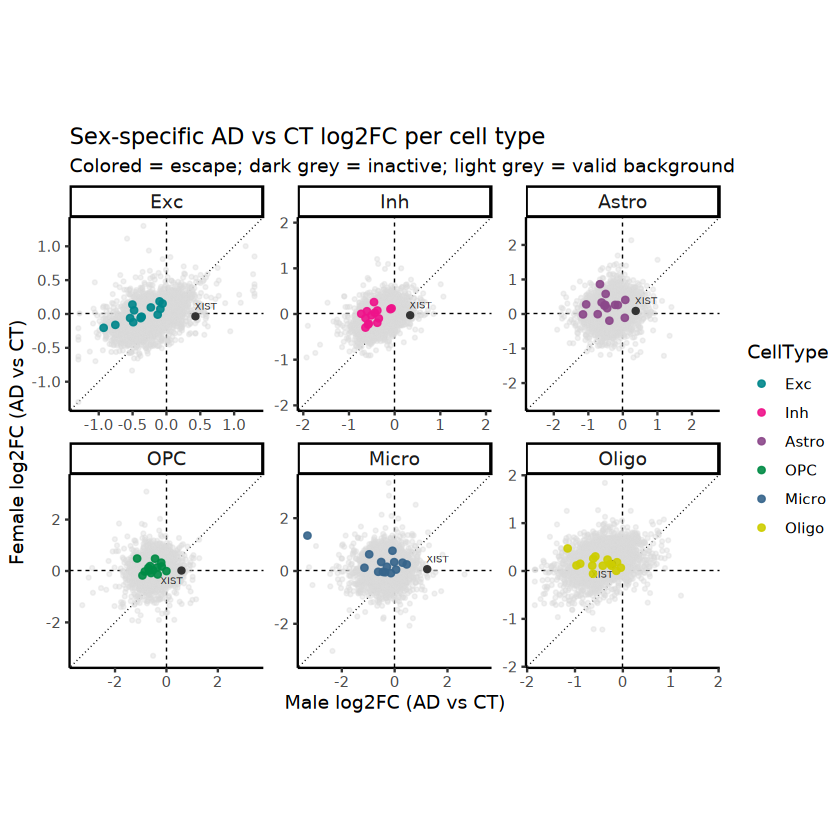

In [ ]:
df_plot <- df_fc %>%
  filter(
    !is.na(F_log2FC),
    !is.na(M_log2FC),
    !CellType %in% c("Endo", "VLMC")
  ) %>%
  mutate(
    is_escape    = Gene %in% escape_genes,
    is_valid_bg  = Gene %in% valid_genes,
    is_inactive  = Gene %in% c("XIST")  
  )

df_range <- df_plot %>%
  group_by(CellType) %>%
  summarise(
    r_x = quantile(abs(M_log2FC), probs = 0.95, na.rm = TRUE),
    r_y = quantile(abs(F_log2FC), probs = 0.95, na.rm = TRUE),
    r   = max(r_x, r_y) * 1.05,
    .groups = "drop"
  )
df_range$r <- pmax(df_range$r, 0.5)

df_plot2 <- df_plot %>%
  left_join(df_range, by = "CellType") %>%
  mutate(
    M_cap = pmax(pmin(M_log2FC, r), -r),
    F_cap = pmax(pmin(F_log2FC, r), -r)
  )

df_limits <- bind_rows(
  df_range %>% transmute(CellType, x_lim =  r, y_lim =  r),
  df_range %>% transmute(CellType, x_lim = -r, y_lim = -r)
)

ggplot() +
  geom_blank(data = df_limits,
             aes(x = x_lim, y = y_lim)) +
  geom_hline(yintercept = 0, linetype = "dashed", size = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", size = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dotted", size = 0.3) +

  geom_point(
    data = df_plot2 %>% filter(is_valid_bg & !is_escape & !is_inactive),
    aes(x = M_cap, y = F_cap),
    color = "grey85",
    alpha = 0.4,
    size  = 0.7
  ) +

  geom_point(
    data = df_plot2 %>% filter(is_inactive),
    aes(x = M_cap, y = F_cap),
    color = "grey20",
    size  = 1.3
  ) +
  geom_text_repel(
    data = df_plot2 %>% filter(is_inactive),
    aes(x = M_cap, y = F_cap, label = Gene),
    color        = "grey20",
    size         = 2,
    max.overlaps = 50,
    box.padding  = 0.2,
    point.padding= 0.1,
    segment.size = 0.2
  ) +

  geom_point(
    data = df_plot2 %>% filter(is_escape),
    aes(x = M_cap, y = F_cap, color = CellType),
    alpha = 0.9,
    size  = 1.4
  ) +

  facet_wrap(~ CellType, scales = "free") +
  scale_color_manual(values = major_base_colors) +
  theme_classic(base_size = 11) +
  theme(
    aspect.ratio = 1,
    strip.text   = element_text(size = 11)
  ) +
  labs(
    x = "Male log2FC (AD vs CT)",
    y = "Female log2FC (AD vs CT)",
    title    = "Sex-specific AD vs CT log2FC per cell type",
    subtitle = "Colored = escape; dark grey = inactive; light grey = valid background"
  )

## OR analysis

In [8]:
X_gene_names <- readLines("x_gene_names.txt")

In [ ]:
expr_mat <- GetAssayData(obj.gage, slot = "data") 
gene_expression_fraction <- Matrix::rowSums(expr_mat > 0) / ncol(expr_mat)

valid_genes <- names(gene_expression_fraction[gene_expression_fraction >= 0.20])

escape_genes   <- df$Gene.name[df$Combined.XCI.status == "escape"]
variable_genes <- df$Gene.name[df$Combined.XCI.status == "variable"]
inactive_genes <- df$Gene.name[df$Combined.XCI.status == "inactive"]

escape_genes   <- escape_genes  [escape_genes   %in% rownames(expr_mat) & escape_genes   %in% valid_genes]
variable_genes <- variable_genes[variable_genes %in% rownames(expr_mat) & variable_genes %in% valid_genes]
inactive_genes <- inactive_genes[inactive_genes %in% rownames(expr_mat) & inactive_genes %in% valid_genes]

all_genes <- valid_genes

gene_class <- ifelse(
  all_genes %in% escape_genes,   "Escape",
  ifelse(all_genes %in% variable_genes, "Variable",
    ifelse(all_genes %in% inactive_genes, "Inactive", "Other")
  )
)

table(gene_class)

gene_df <- data.frame(
  gene = all_genes,
  class = gene_class,
  expr_frac = gene_expression_fraction[all_genes]
)

gene_df <- gene_df[order(gene_df$expr_frac, decreasing = TRUE), ]

print(table(gene_df$class))

all_genes <- gene_df$gene
gene_class <- gene_df$class


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


gene_class
  Escape Inactive    Other Variable 
      15       69     4050       15 


  Escape Inactive    Other Variable 
      15       69     4050       15 


In [ ]:
expr_mat <- FetchData(obj.gage, vars = all_genes)  
meta     <- obj.gage@meta.data

is_expr  <- expr_mat > threshold   

group     <- meta[[group_var]]     
condition <- meta[["condition"]]   

cell_type_var <- "major_cell_type"
cell_types    <- sort(unique(meta[[cell_type_var]]))

compute_for_celltype <- function(ct) {
  idx_ct <- which(meta[[cell_type_var]] == ct)
  if (length(idx_ct) == 0) return(NULL)

  idx_F_AD <- which(group == "Female" & condition == "AD" & meta[[cell_type_var]] == ct)
  idx_M_AD <- which(group == "Male"   & condition == "AD" & meta[[cell_type_var]] == ct)
  idx_F_CT <- which(group == "Female" & condition == "CT" & meta[[cell_type_var]] == ct)
  idx_M_CT <- which(group == "Male"   & condition == "CT" & meta[[cell_type_var]] == ct)

  n_F_AD <- length(idx_F_AD)
  n_M_AD <- length(idx_M_AD)
  n_F_CT <- length(idx_F_CT)
  n_M_CT <- length(idx_M_CT)

  if (any(c(n_F_AD, n_M_AD, n_F_CT, n_M_CT) == 0)) {
    return(tibble(
      gene          = all_genes,
      class         = gene_class,
      cell_type     = ct,
      or_ad         = NA_real_,
      or_ct         = NA_real_,
      log2_or_ad    = NA_real_,
      log2_or_ct    = NA_real_,
      delta_log2_or = NA_real_,
      p_value_ad    = NA_real_
    ))
  }

  nexp_F_AD <- colSums(is_expr[idx_F_AD, , drop = FALSE])
  nexp_M_AD <- colSums(is_expr[idx_M_AD, , drop = FALSE])
  nexp_F_CT <- colSums(is_expr[idx_F_CT, , drop = FALSE])
  nexp_M_CT <- colSums(is_expr[idx_M_CT, , drop = FALSE])

  compute_or_for_gene_ct <- function(i) {
    g  <- all_genes[i]
    cl <- gene_class[i]

    a1 <- nexp_F_AD[i]; b1 <- n_F_AD - a1
    c1 <- nexp_M_AD[i]; d1 <- n_M_AD - c1
    tbl_ad <- matrix(c(a1, b1, c1, d1), nrow = 2, byrow = TRUE)

    a2 <- nexp_F_CT[i]; b2 <- n_F_CT - a2
    c2 <- nexp_M_CT[i]; d2 <- n_M_CT - c2
    tbl_ct <- matrix(c(a2, b2, c2, d2), nrow = 2, byrow = TRUE)

    if (any(is.na(tbl_ad)) || any(tbl_ad < 0) ||
        any(is.na(tbl_ct)) || any(tbl_ct < 0)) {
      return(tibble(
        gene          = g,
        class         = cl,
        cell_type     = ct,
        or_ad         = NA_real_,
        or_ct         = NA_real_,
        log2_or_ad    = NA_real_,
        log2_or_ct    = NA_real_,
        delta_log2_or = NA_real_,
        p_value_ad    = NA_real_
      ))
    }

    fisher_ad <- fisher.test(tbl_ad)
    fisher_ct <- fisher.test(tbl_ct)

    or_ad <- as.numeric(fisher_ad$estimate)
    or_ct <- as.numeric(fisher_ct$estimate)

    log2_or_ad    <- log2(or_ad)
    log2_or_ct    <- log2(or_ct)
    delta_log2_or <- log2_or_ad - log2_or_ct

    tibble(
      gene          = g,
      class         = cl,
      cell_type     = ct,
      or_ad         = or_ad,
      or_ct         = or_ct,
      log2_or_ad    = log2_or_ad,
      log2_or_ct    = log2_or_ct,
      delta_log2_or = delta_log2_or,
      p_value_ad    = fisher_ad$p.value
    )
  }

  map_dfr(seq_along(all_genes), compute_or_for_gene_ct)
}

stat_df_ct <- map_dfr(cell_types, compute_for_celltype)

In [29]:
stat_df <- stat_df_ct %>%
  dplyr::filter(gene != "XIST") %>%    
  dplyr::filter(gene != "MALAT1")  %>% 
  dplyr::mutate(
    z_or_ad = scale(log2_or_ad)[, 1],    
    z_or_ct = scale(log2_or_ct)[, 1]
  )

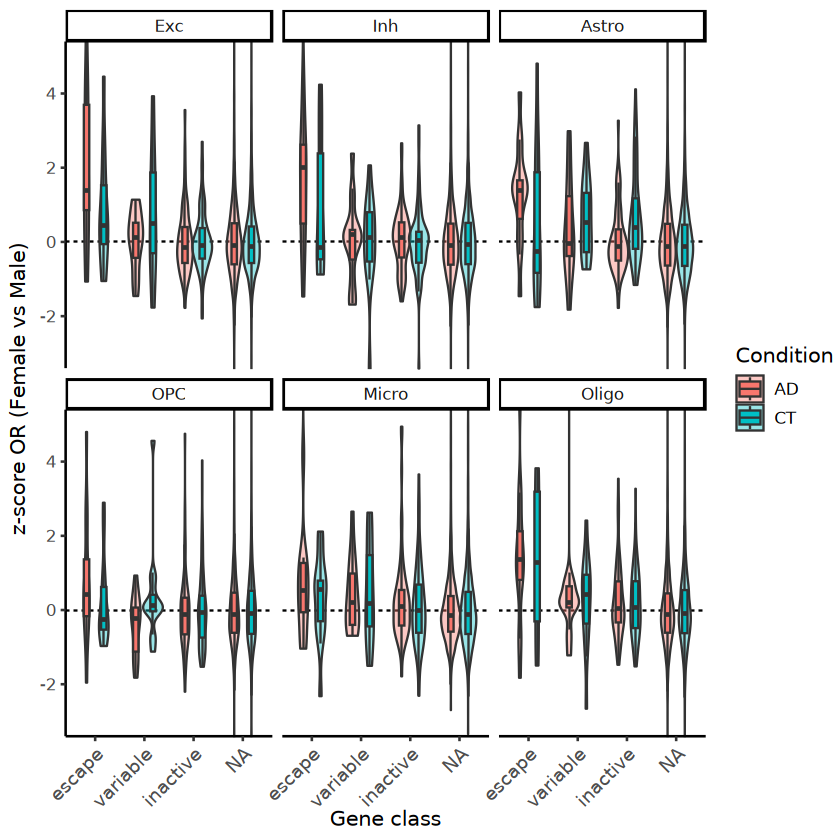

In [ ]:
stat_df2 <- stat_df %>%
  dplyr::filter(gene != "XIST") %>%
  dplyr::filter(cell_type != "VLMC") %>%
  dplyr::filter(cell_type != "Endo") %>%
  group_by(cell_type) %>%  
  filter(is.finite(or_ad), is.finite(or_ct)) %>%
  dplyr::mutate(
    z_or_ad = as.numeric(scale(or_ad)),
    z_or_ct = as.numeric(scale(or_ct))
  ) %>%
  ungroup()

stat_df2 <- stat_df2 %>%
  mutate(
    class = as.character(class),
    class = ifelse(is.na(class), "other", class),
    class = factor(class,
                   levels = c("escape", "variable", "inactive", "other"))
  )

df_long <- stat_df2 %>%
  dplyr::select(gene, class, cell_type, z_or_ad, z_or_ct) %>%
  mutate(class = factor(class,
                        levels = c("escape", "variable", "inactive"))) %>%
  pivot_longer(
    cols      = starts_with("z_or_"),
    names_to  = "condition",
    values_to = "z_or"
  ) %>%
  mutate(condition = ifelse(condition == "z_or_ad", "AD", "CT"))

p <- ggplot(df_long, aes(x = class, y = z_or, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_violin(trim = TRUE, alpha = 0.4,
              position = position_dodge(width = 0.7), width = 0.8) +
  geom_boxplot(width = 0.22,
               position = position_dodge(width = 0.7),
               outlier.shape = NA) +
  coord_cartesian(ylim = c(-3, 5)) +
  facet_wrap(~ cell_type) +  
  theme_classic(base_size = 12) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(size = 11, angle = 45, hjust = 1),
    axis.title.x = element_text(margin = margin(t = 5)),
    axis.title.y = element_text(margin = margin(r = 5))
  ) +
  labs(
    x = "Gene class",
    y = "z-score OR (Female vs Male)",
    fill = "Condition"
  )

p

In [ ]:
expr_all <- FetchData(seurat_obj, vars = all_genes)

meta <- seurat_obj@meta.data   

df_long_expr <- expr_all %>%
  mutate(cell = rownames(.)) %>%
  as_tibble() %>%
  pivot_longer(
    cols = all_of(all_genes),
    names_to = "gene",
    values_to = "expr"
  ) %>%
  left_join(
    meta %>%
      mutate(cell = rownames(.)) %>%
      dplyr::select(cell, sex, condition), 
    by = "cell"
  )

compute_log2_ratio <- function(df_sub, gene_name) {
  df_gene <- df_sub %>% filter(gene == gene_name)

  summary_gene <- df_gene %>%
    group_by(condition, sex) %>%
    summarise(mean_expr = mean(expr), .groups = "drop")

  get_ratio <- function(cond) {
    female_mean <- summary_gene$mean_expr[summary_gene$condition == cond &
                                          summary_gene$sex == "Female"]
    male_mean   <- summary_gene$mean_expr[summary_gene$condition == cond &
                                          summary_gene$sex == "Male"]

    log2((female_mean + 1e-6) / (male_mean + 1e-6))
  }

  log2_ratio_ad <- get_ratio("AD")
  log2_ratio_ct <- get_ratio("CT")
  delta_log2    <- log2_ratio_ad - log2_ratio_ct

  list(
    log2_ratio_ad = log2_ratio_ad,
    log2_ratio_ct = log2_ratio_ct,
    delta_log2_ratio = delta_log2
  )
}

stat_df_continuous <- map2_df(all_genes, gene_class, function(g, cls) {
  ratios <- compute_log2_ratio(df_long_expr, g)

  tibble(
    gene = g,
    class = cls,
    log2_ratio_ad  = ratios$log2_ratio_ad,
    log2_ratio_ct  = ratios$log2_ratio_ct,
    delta_log2_ratio = ratios$delta_log2_ratio
  )
})

head(stat_df_continuous)


Attaching package: ‘purrr’


The following object is masked from ‘package:IRanges’:

    reduce


The following object is masked from ‘package:clusterProfiler’:

    simplify




gene,class,log2_ratio_ad,log2_ratio_ct,delta_log2_ratio
<chr>,<chr>,<dbl>,<dbl>,<dbl>
IL1RAPL1,variable,-0.01266114,-0.01162091,-0.001040228
FTX,inactive,0.17752986,-0.11094658,0.288476434
DMD,inactive,0.19403412,-0.19488179,0.388915911
GPM6B,escape,0.13382971,-0.12057093,0.254400639
FRMPD4,inactive,0.28097548,-0.09137994,0.372355421
ATRX,inactive,0.16051580,-0.20851454,0.369030340


In [48]:
stat_df_continuous <- stat_df_continuous %>%
  dplyr::filter(gene != "XIST") %>% 
  dplyr::mutate(
    z_log2_ratio_ad = as.numeric(scale(log2_ratio_ad)),
    z_log2_ratio_ct = as.numeric(scale(log2_ratio_ct))
  ) %>%
  ungroup()

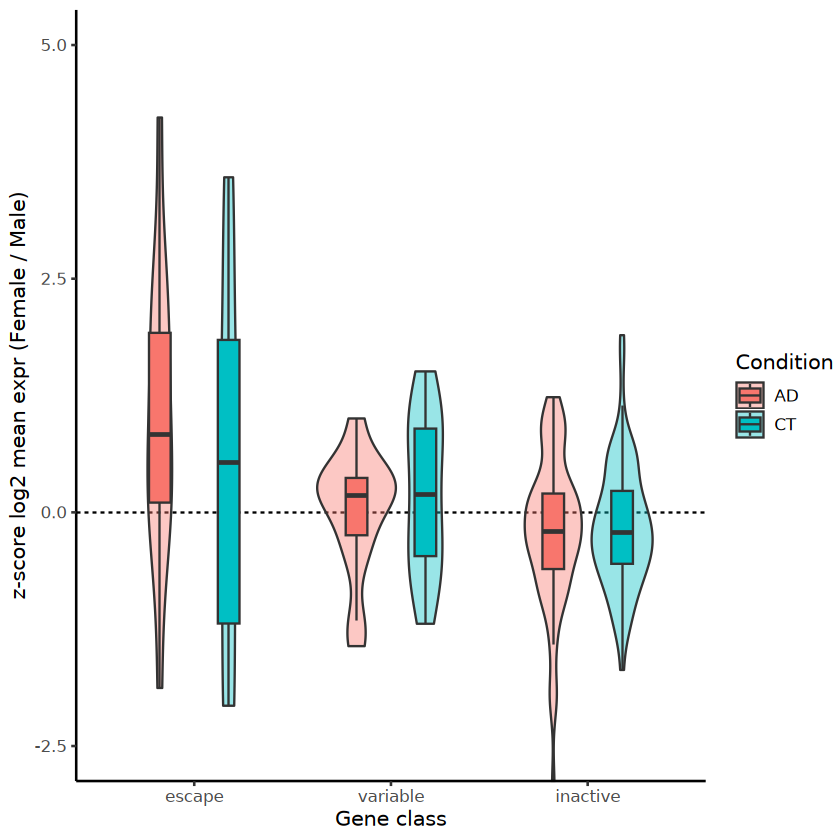

In [ ]:
stat_df_continuous <- stat_df_continuous %>%
  mutate(class = factor(class, levels = c("escape", "variable", "inactive")))

df_long_ratio <- stat_df_continuous %>%
  dplyr::select(gene, class, z_log2_ratio_ad, z_log2_ratio_ct) %>%
  pivot_longer(
    cols = c(z_log2_ratio_ad, z_log2_ratio_ct),
    names_to = "condition",
    values_to = "z_log2_ratio"
  ) %>%
  mutate(condition = ifelse(condition == "z_log2_ratio_ad", "AD", "CT"))

p_ratio <- ggplot(df_long_ratio,
                  aes(x = class, y = z_log2_ratio, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_violin(trim = TRUE, alpha = 0.4,
              position = position_dodge(width = 0.7), width = 0.8) +
  geom_boxplot(width = 0.22,
               position = position_dodge(width = 0.7),
               outlier.shape = NA) +
  coord_cartesian(ylim = c(-2.5, 5)) +    
  theme_classic(base_size = 12) +
  labs(
    x = "Gene class",
    y = "z-score log2 mean expr (Female / Male)",
    fill = "Condition"
  )

p_ratio

## Permutation tests

In [15]:
escape_genes <- escape_genes[escape_genes != "XIST"]

In [ ]:
set.seed(42)
n_sample <- length(escape_genes)
n_iter <- 1000
seurat_obj <- obj.gage
all_needed_genes <- unique(c(escape_genes, x_non_escape))
expr_all <- FetchData(seurat_obj, vars = all_needed_genes)

meta <- seurat_obj@meta.data
expr_meta <- tibble::tibble(
  cell = rownames(meta),
  sex = meta$sex,
  condition = meta$condition
)

escape_sum <- rowSums(expr_all[, escape_genes])

## === Female ===
female_idx <- expr_meta$sex == "Female"
expr_meta_female <- expr_meta[female_idx, ]
escape_female <- escape_sum[female_idx]

group_AD_f <- expr_meta_female$condition == "AD"
group_CT_f <- expr_meta_female$condition == "CT"

escape_diff_female <- mean(escape_female[group_AD_f]) - mean(escape_female[group_CT_f])

random_diff_female <- vapply(1:n_iter, function(i) {
  sampled_genes <- sample(x_non_escape, n_sample)
  random_sum <- rowSums(expr_all[, sampled_genes])[female_idx]
  mean(random_sum[group_AD_f]) - mean(random_sum[group_CT_f])
}, numeric(1))


## === Male ===
male_idx <- expr_meta$sex == "Male"
expr_meta_male <- expr_meta[male_idx, ]
escape_male <- escape_sum[male_idx]

group_AD_m <- expr_meta_male$condition == "AD"
group_CT_m <- expr_meta_male$condition == "CT"

escape_diff_male <- mean(escape_male[group_AD_m]) - mean(escape_male[group_CT_m])

random_diff_male <- vapply(1:n_iter, function(i) {
  sampled_genes <- sample(x_non_escape, n_sample)
  random_sum <- rowSums(expr_all[, sampled_genes])[male_idx]
  mean(random_sum[group_AD_m]) - mean(random_sum[group_CT_m])
}, numeric(1))

In [ ]:
df_rand <- bind_rows(
  tibble(diff = random_diff_female, sex = "Female"),
  tibble(diff = random_diff_male,   sex = "Male")
)

df_escape <- tibble(
  sex         = c("Female",          "Male"),
  escape_diff = c(escape_diff_female, escape_diff_male)
)

df_lab <- df_rand %>%
  left_join(df_escape, by = "sex") %>%
  group_by(sex) %>%
  summarise(
    p = mean(diff >= escape_diff),
    .groups = "drop"
  ) %>%
  mutate(
    label = paste0("p = ", signif(p, 2)),
    x = -Inf,
    y = Inf
  )

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Mean(AD) − Mean(CT) of summed expression' in 'mbcsToSbcs': - substituted for − (U+2212)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Permutation test of AD–CT expression shift' in 'mbcsToSbcs': - substituted for – (U+2013)”


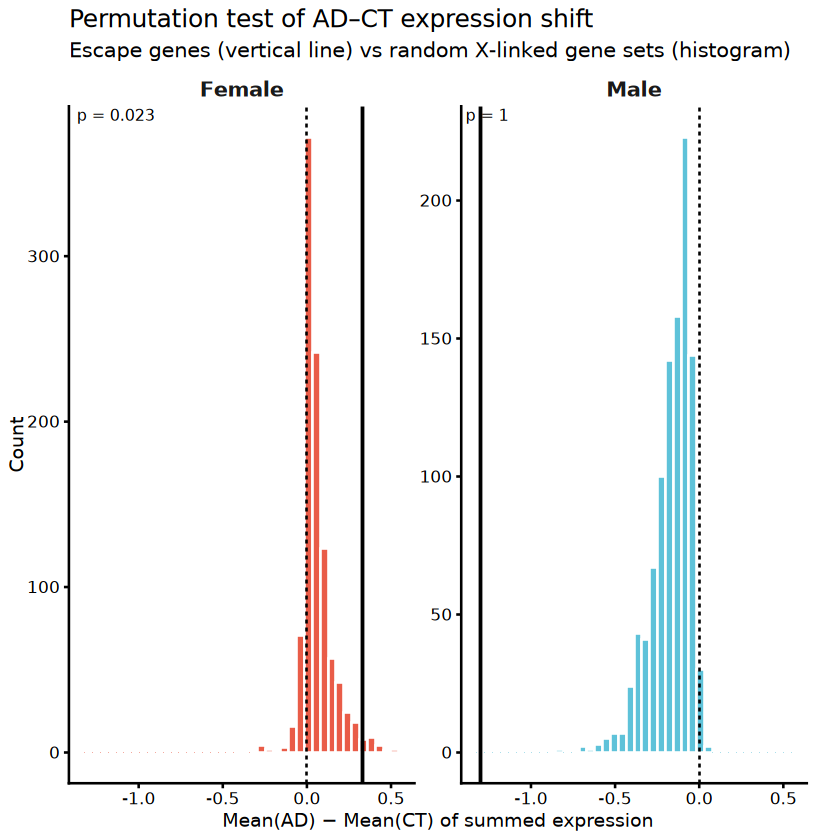

In [ ]:
fill_colors <- c(Female = "#E64B35FF", Male = "#4DBBD5FF")

p <- ggplot(df_rand, aes(x = diff, fill = sex)) +
  geom_histogram(bins = 40, color = "white", alpha = 0.9) +
  facet_wrap(~ sex, nrow = 1, scales = "free_y") +
  scale_fill_manual(values = fill_colors, guide = "none") +
  geom_vline(
    data = df_escape,
    aes(xintercept = escape_diff),
    color = "black", linetype = "solid", linewidth = 0.8
  ) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  geom_text(
    data = df_lab,
    aes(x = x, y = y, label = label),
    hjust = -0.1, vjust = 1.2,
    size = 3.2,
    inherit.aes = FALSE
  ) +
  coord_cartesian(clip = "off") +
  theme_classic(base_size = 12) +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 11),
    axis.text  = element_text(size = 10),
    plot.margin = margin(5.5, 20, 5.5, 5.5)
  ) +
  labs(
    x = "Mean(AD) − Mean(CT) of summed expression",
    y = "Count",
    title = "Permutation test of AD–CT expression shift",
    subtitle = "Escape genes (vertical line) vs random X-linked gene sets (histogram)"
  )

p